# 딥러닝 (Deep Learning) - 캘리포니아 주택 가격 예측
## TensorFlow / Keras 를 이용한 회귀(Regression) 모델링

In [17]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow 버전: {tf.__version__}')

TensorFlow 버전: 2.15.0


## 1. 딥러닝이란?

### 머신러닝 vs 딥러닝

> **머신러닝**: 사람이 특징(feature)을 직접 설계 → 모델이 학습  
> **딥러닝**: 데이터를 넣으면 특징까지 **스스로** 학습

---

### 신경망(Neural Network) 구조

```
[입력층 Input]  →  [은닉층 Hidden]  →  [은닉층 Hidden]  →  [출력층 Output]
  8개 변수              64개 뉴런            32개 뉴런            1개 (집값)
```

| 층 | 역할 |
|---|---|
| **입력층 (Input)** | 데이터를 받아들이는 입구 (변수 개수 = 뉴런 수) |
| **은닉층 (Hidden)** | 패턴을 학습하는 층, 여러 개 쌓을수록 복잡한 패턴 학습 |
| **출력층 (Output)** | 최종 예측값 출력 (회귀=1개, 분류=클래스 수) |

---

### 활성화 함수 (Activation Function)

뉴런의 출력값에 비선형성을 추가 → 복잡한 패턴 학습 가능

| 함수 | 수식 | 용도 |
|---|---|---|
| **ReLU** | max(0, x) | 은닉층 기본값 (빠르고 안정적) |
| **Sigmoid** | 1/(1+e^-x) | 이진분류 출력층 |
| **Softmax** | e^x / Σe^x | 다중분류 출력층 |
| **Linear** | x | 회귀 출력층 (기본값, 생략 가능) |

### 📝 시험 출제 포인트
- 은닉층 활성화 함수 → **ReLU**
- 이진분류 출력층 → **Sigmoid** + loss: **binary_crossentropy**
- 다중분류 출력층 → **Softmax** + loss: **categorical_crossentropy**
- 회귀 출력층 → **없음(Linear)** + loss: **mse**

## 2. 데이터 로드 및 탐색

In [18]:
# 데이터 로드
df = pd.read_csv(r'pandas/data/california_housing_test.csv')
print(f'데이터 크기: {df.shape}')
df.head()

데이터 크기: (3000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [19]:
# 기본 정보 및 결측치 확인
print('=== 컬럼 정보 ===')
df.info()
print()
print('=== 결측치 ===')  
print(df.isnull().sum())

=== 컬럼 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB

=== 결측치 ===
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [20]:
# 기술통계
df.describe().round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,-119.59,35.64,28.85,2599.58,529.95,1402.80,489.91,3.81,205846.28
std,1.99,2.13,12.56,2155.59,415.65,1030.54,365.42,1.85,113119.69
min,-124.18,32.56,1.00,6.00,2.00,5.00,2.00,0.50,22500.00
25%,-121.81,33.93,18.00,1401.00,291.00,780.00,273.00,2.54,121200.00
50%,-118.48,34.27,29.00,2106.00,437.00,1155.00,409.50,3.49,177650.00
75%,-118.02,37.69,37.00,3129.00,636.00,1742.75,597.25,4.66,263975.00
max,-114.49,41.92,52.00,30450.00,5419.00,11935.00,4930.00,15.00,500001.00


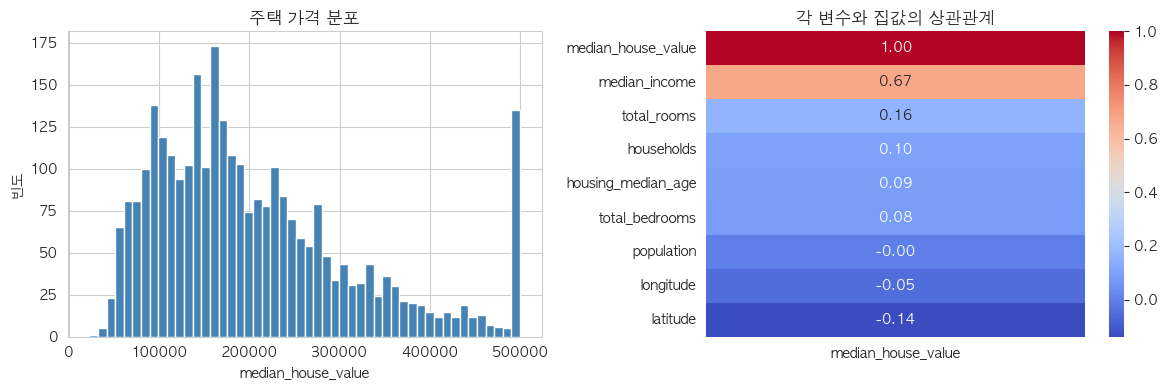

집값 평균: 205,846
집값 범위: 22,500 ~ 500,001


In [21]:
# 타겟 변수 분포 및 상관관계
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 히스토그램
axes[0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('주택 가격 분포')
axes[0].set_xlabel('median_house_value')
axes[0].set_ylabel('빈도')

# 상관관계 히트맵
corr = df.corr()
sns.heatmap(corr[['median_house_value']].sort_values('median_house_value', ascending=False),
            annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('각 변수와 집값의 상관관계')

plt.tight_layout()
plt.show()

print(f"집값 평균: {df['median_house_value'].mean():,.0f}")
print(f"집값 범위: {df['median_house_value'].min():,.0f} ~ {df['median_house_value'].max():,.0f}")

## 3. 데이터 전처리

### 딥러닝에서 스케일링이 필수인 이유

> 신경망은 **가중치 × 입력값** 으로 계산합니다.  
> 변수 단위가 다르면 큰 값의 변수가 학습을 지배하고,  
> 경사하강법(Gradient Descent)이 불안정해집니다.

```
total_rooms   : 67 ~ 37,937  (범위 매우 큼)
median_income : 0.5 ~ 15     (범위 작음)
→ 스케일링 없이는 total_rooms가 학습을 지배함
```
→ **StandardScaler** 로 모든 변수를 평균=0, 표준편차=1 로 통일

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# X(입력), y(타겟) 분리
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

print(f'입력 변수: {X.columns.tolist()}')
print(f'X shape: {X.shape}, y shape: {y.shape}')

# 학습/테스트 분리 (8:2) — 회귀이므로 stratify 없음
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 스케일링 — 딥러닝은 스케일링 필수
# fit은 X_train으로만 → X_test는 transform만 (데이터 누수 방지)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}, Test: {X_test_s.shape}')
print(f'스케일링 후 평균: {X_train_s.mean():.4f}, 표준편차: {X_train_s.std():.4f}')

입력 변수: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
X shape: (3000, 8), y shape: (3000,)
Train: (2400, 8), Test: (600, 8)
스케일링 후 평균: 0.0000, 표준편차: 1.0000


## Keras 란?

> **Keras = 딥러닝 모델을 쉽게 만들 수 있도록 설계된 고수준(high-level) Python API**

복잡한 텐서 연산을 직접 다루지 않고, **레고 블록을 조립하듯** 신경망을 만들 수 있게 해주는 도구입니다.

### Keras vs TensorFlow 관계

```
┌─────────────────────────────────┐
│         Keras (고수준)           │  ← 사용자가 직접 사용
│   Sequential, Dense, fit() 등   │
├─────────────────────────────────┤
│      TensorFlow (저수준)         │  ← Keras가 내부적으로 호출
│   tensor 연산, GPU 처리, 미분    │
└─────────────────────────────────┘
```

- **TensorFlow**: 엔진 (강력하지만 복잡)
- **Keras**: 운전대 (TensorFlow 위에서 쉽게 조작)
- TensorFlow 2.0부터 Keras는 `tf.keras`로 **완전히 통합**되어 TensorFlow의 표준 모델링 인터페이스가 되었습니다.

```python
# 두 가지 import 방식 (동일)
from tensorflow import keras
from tensorflow.keras import layers, models
```

### 왜 Keras를 쓰는가?

| 장점 | 설명 |
|------|------|
| **간결함** | 몇 줄로 신경망 구성 가능 |
| **직관적** | 층(layer)을 순서대로 쌓는 방식 |
| **빠른 프로토타이핑** | 아이디어 → 코드까지 시간 단축 |
| **풍부한 기능** | 콜백, 전처리, 사전학습 모델 내장 |
| **호환성** | TensorFlow의 모든 기능을 그대로 사용 가능 |

### Keras 모델을 만드는 3가지 방식

**① Sequential API** — 가장 간단, 일자형 모델 (대부분 이걸로 충분)
```python
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
  Dense(64, activation='relu', input_shape=(13,)),
  Dense(32, activation='relu'),
  Dense(1)
])
```

**② Functional API** — 분기/합치기 가능, 복잡한 모델
```python
from tensorflow.keras import Input, Model

inputs = Input(shape=(13,))
x = Dense(64, activation='relu')(inputs)
outputs = Dense(1)(x)
model = Model(inputs, outputs)
```

**③ Subclassing** — 완전한 커스터마이징 (연구/고급 사용)

### Keras 주요 모듈

| 모듈 | 역할 |
|------|------|
| `keras.layers` | Dense, Conv2D, LSTM, Dropout 등 **층(layer)** |
| `keras.models` | Sequential, Model |
| `keras.optimizers` | Adam, SGD, RMSprop 등 **최적화 알고리즘** |
| `keras.losses` | mse, binary_crossentropy 등 **손실 함수** |
| `keras.metrics` | accuracy, mae, AUC 등 **평가 지표** |
| `keras.callbacks` | EarlyStopping, ModelCheckpoint 등 **학습 보조** |
| `keras.applications` | VGG, ResNet 등 **사전학습 모델** |

### Keras 표준 학습 워크플로우 (4단계)

```python
# 1. 모델 정의 (층 쌓기)
model = Sequential([
  Dense(64, activation='relu', input_shape=(8,)),
  Dense(32, activation='relu'),
  Dense(1)
])

# 2. 컴파일 (loss, optimizer, metrics 설정)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. 학습
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50, batch_size=32)

# 4. 평가 / 예측
model.evaluate(X_test, y_test)
model.predict(X_new)
```

### 핵심 요약

> Keras는 **TensorFlow를 쉽게 쓰게 해주는 고수준 API**이며,
> **레고처럼 층(layer)을 쌓아 신경망을 만든다.**
> 시험에서는 `model.compile()` → `model.fit()` → `model.evaluate()` → `model.predict()` **4단계 흐름**이 반드시 출제된다.

---


## 4. Keras 딥러닝 모델 구성

### Sequential API

```python
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),  # 은닉층 1
    layers.Dense(32, activation='relu'),                     # 은닉층 2
    layers.Dense(1)                                          # 출력층 (회귀)
])
```

| 항목 | 설명 |
|---|---|
| **Dense** | 완전연결층 — 이전 층의 모든 뉴런과 연결 |
| **units** | 해당 층의 뉴런(노드) 수 |
| **activation** | 활성화 함수 (relu, sigmoid, softmax...) |
| **input_shape** | 입력 변수 개수 (첫 번째 층에만 지정) |

---

### Activation (활성화 함수) 상세

#### 왜 활성화 함수가 필요한가?

> 활성화 함수가 **없으면** 아무리 층을 쌓아도 `y = ax + b` 와 같은 단순 직선밖에 표현 못합니다.  
> 활성화 함수가 **비선형성**을 추가해줘야 곡선, 패턴 등 복잡한 관계를 학습할 수 있습니다.

#### 사용 가능한 활성화 함수 목록

| 함수 | 수식 | 출력 범위 | 용도 | 장단점 |
|---|---|---|---|---|
| **ReLU** | max(0, x) | 0 ~ +∞ | **은닉층 기본** | 빠르고 안정적, 음수는 0으로 버림 |
| **LeakyReLU** | x>0→x, x≤0→0.01x | -∞ ~ +∞ | 은닉층 (ReLU 개선) | 음수도 살려서 정보 보존 |
| **Sigmoid** | 1/(1+e^-x) | 0 ~ 1 | **이진분류 출력층** | 확률로 해석 가능 |
| **Softmax** | e^x / Σe^x | 0 ~ 1 (합=1) | **다중분류 출력층** | 클래스별 확률 합이 1 |
| **Tanh** | (e^x-e^-x)/(e^x+e^-x) | -1 ~ 1 | 은닉층 (RNN 등) | 0 중심이라 학습에 유리 |
| **Linear** | x (변환 없음) | -∞ ~ +∞ | **회귀 출력층** | 숫자 그대로 출력 |

#### 어떤 상황에 어떤 함수를 쓰는가?

```
은닉층  →  ReLU     (기본, 99% 이걸 씀)
           LeakyReLU (ReLU로 학습이 안 될 때 시도)

출력층  →  문제 유형에 따라 결정:
           회귀      → Linear   (생략 = 기본값이 Linear)
           이진분류   → Sigmoid  (0~1 확률 출력)
           다중분류   → Softmax  (클래스별 확률, 합=1)
```

> **시험 핵심:** 은닉층 = `relu`, 출력층은 문제 유형에 따라 결정

---

### compile 매개변수 상세

```python
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
```

compile은 **"이 모델을 어떻게 학습시킬 것인가"** 를 설정하는 단계입니다.

---

#### ① optimizer — 가중치를 어떻게 업데이트할 것인가?

> 경사하강법에서 "한 걸음을 어떤 방식으로 내딛을지" 결정

| Optimizer | 특징 | 사용 시점 |
|---|---|---|
| **SGD** | 가장 기본, 학습률 고정 | 학습 과정을 세밀히 제어할 때 |
| **Adam** | 학습률 **자동 조절** + 관성(momentum) | **기본값, 대부분 이걸 씀** |
| **RMSprop** | Adam과 비슷, RNN에서 자주 사용 | 시계열/순환신경망 |
| **AdamW** | Adam + L2 정규화 개선 | 과적합 방지 강화 |

**Adam을 기본으로 쓰는 이유:**
- 학습률을 변수마다 **자동으로 다르게 조절** → 사람이 튜닝할 필요 적음
- 학습 초반에 빠르게 수렴, 후반에 세밀하게 조정
- 대부분의 데이터에서 SGD보다 빠르고 안정적

```python
# 기본 사용
model.compile(optimizer='adam', ...)

# 학습률을 직접 조정하고 싶을 때
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), ...)
```

---

#### ② loss — 오차를 어떻게 계산할 것인가?

> 예측값과 실제값의 차이를 숫자 하나로 표현하는 함수  
> 모델은 이 loss를 **최소화**하는 방향으로 가중치를 수정합니다

| Loss 함수 | 설명 | 문제 유형 |
|---|---|---|
| **mse** | (예측-실제)²의 평균 | **회귀** |
| **mae** | |예측-실제|의 평균 | 회귀 (이상치에 강건) |
| **binary_crossentropy** | 이진 확률 오차 | **이진분류** |
| **categorical_crossentropy** | 다중 확률 오차 | **다중분류 (원핫 라벨)** |
| **sparse_categorical_crossentropy** | 위와 동일 | **다중분류 (정수 라벨)** |

**이 모델에서 `mse`를 쓰는 이유:**
- 집값 예측 = **회귀** 문제 → mse가 표준
- mse는 큰 오차에 더 큰 패널티를 줌 (제곱이므로)
- 이상치가 많으면 mae가 더 적합할 수 있음

---

#### ③ metrics — 학습 중 무엇을 모니터링할 것인가?

> loss와 별개로, 학습 도중에 사람이 **성능을 직관적으로** 파악하기 위한 지표

```
loss (mse)    → 모델이 내부적으로 가중치 업데이트에 사용 (수학적 최적화용)
metrics (mae) → 우리가 눈으로 볼 때 직관적으로 파악하는 용도
```

**loss=mse 인데 metrics=['mae'] 로 따로 쓰는 이유:**

```
mse = 25,000,000,000  → 숫자가 너무 커서 해석 어려움 (제곱이라)
mae =        50,000   → "평균 5만 달러 오차" → 바로 이해 가능
```

> **핵심:** loss는 **모델이 학습하는 기준**, metrics는 **사람이 보는 기준**

| metrics | 의미 | 문제 유형 |
|---|---|---|
| **mae** | 평균 절대 오차 (단위가 원래 값과 같아 해석 쉬움) | 회귀 |
| **accuracy** | 정확도 (맞힌 비율) | 분류 |

---

### 📝 시험 출제 빈출 조합

| 문제 유형 | 은닉층 activation | 출력층 activation | loss | metrics |
|---|---|---|---|---|
| **회귀** | relu | 없음 | mse | mae |
| **이진분류** | relu | sigmoid | binary_crossentropy | accuracy |
| **다중분류** | relu | softmax | categorical_crossentropy | accuracy |

In [23]:
# ── 모델 구성 ──────────────────────────────────────────────
model = keras.Sequential([
    # 은닉층 1: 뉴런 64개, ReLU 활성화, 입력 변수 8개
    layers.Dense(64, activation='relu', input_shape=(X_train_s.shape[1],)),
    # 은닉층 2: 뉴런 32개, ReLU 활성화
    layers.Dense(32, activation='relu'),
    # 출력층: 뉴런 1개, 활성화 함수 없음 (회귀 = linear)
    layers.Dense(1)
], name='housing_model')

# ── 컴파일 ─────────────────────────────────────────────────
# optimizer='adam' : 학습률 자동 조절 (가장 많이 쓰는 옵티마이저)
# loss='mse'       : 평균제곱오차 (회귀 표준 손실함수)
# metrics=['mae']  : 학습 중 MAE도 함께 모니터링
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "housing_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_20 (Dense)            (None, 64)                576       
                                                                 
 dense_21 (Dense)            (None, 32)                2080      
                                                                 
 dense_22 (Dense)            (None, 1)                 33        
                                                                 
Total params: 2689 (10.50 KB)
Trainable params: 2689 (10.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 5. 학습 — Callback 활용

| Callback | 기능 |
|---|---|
| **EarlyStopping** | val_loss가 개선 없으면 조기 종료 (과적합 방지) |
| **ReduceLROnPlateau** | 손실이 줄지 않으면 학습률 자동 감소 |

```python
EarlyStopping(
    monitor='val_loss',       # 모니터링 지표
    patience=10,              # 개선 없는 epoch 허용 횟수
    restore_best_weights=True # 최적 가중치로 복원
)
```

### 📝 시험 출제 포인트
- `patience` : 몇 epoch 기다릴지
- `restore_best_weights=True` : 종료 시점이 아닌 **최적 시점** 가중치 사용
- `validation_split=0.2` : 학습 데이터의 20%를 자동으로 검증에 사용

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    # val_loss가 10 epoch 개선 없으면 중단, 최적 가중치 복원
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    # val_loss가 5 epoch 개선 없으면 학습률 0.5배 감소
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=5, min_lr=1e-6, verbose=0),
]

# epochs=200   : 최대 200번 반복 (EarlyStopping으로 조기 종료됨)
# batch_size=32: 한 번에 32개 샘플씩 학습 (메모리/속도 균형)
# validation_split=0.2 : 학습 데이터 20%를 검증에 사용
history = model.fit(
    X_train_s, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=0
)

print(f'실제 학습 epoch 수: {len(history.history["loss"])}')

실제 학습 epoch 수: 200


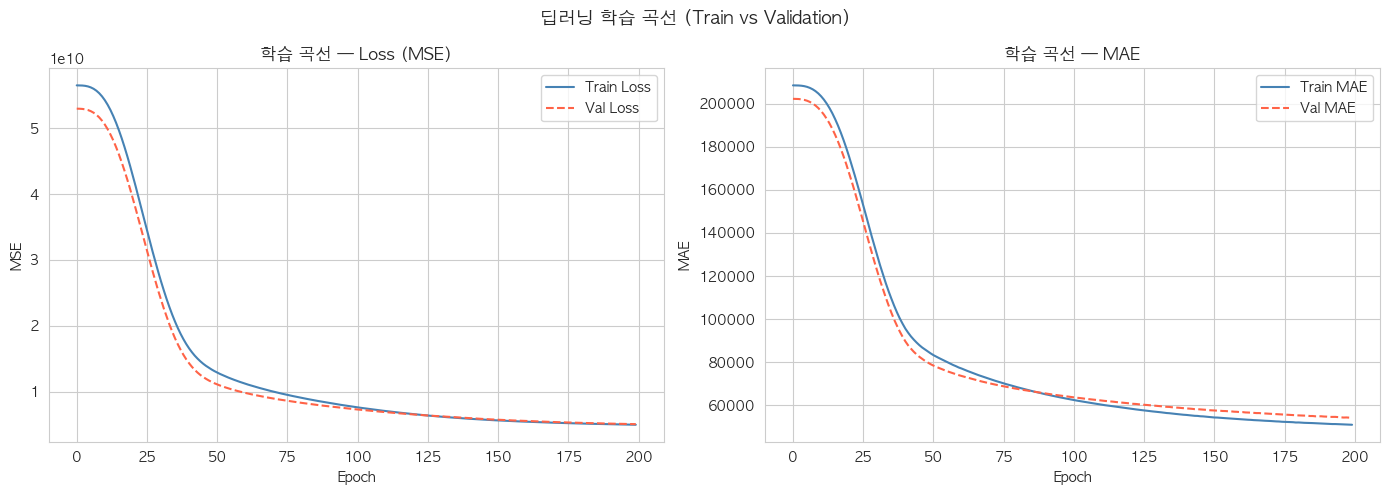

→ val_loss가 올라가기 시작하면 과적합 구간


In [25]:
# ── 학습 곡선 시각화 ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss (MSE) 곡선: Train vs Validation
axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
axes[0].set_title('학습 곡선 — Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

# MAE 곡선
axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='tomato', linestyle='--')
axes[1].set_title('학습 곡선 — MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('딥러닝 학습 곡선 (Train vs Validation)', fontsize=13)
plt.tight_layout()
plt.show()
print('→ val_loss가 올라가기 시작하면 과적합 구간')

## 6. 모델 평가

In [26]:
# predict(): 2D 배열 반환 → flatten()으로 1D 변환
y_pred_train = model.predict(X_train_s, verbose=0).flatten()
y_pred_test  = model.predict(X_test_s,  verbose=0).flatten()

def print_reg_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    mape = (abs(y_true.values - y_pred) / y_true.values).mean()
    print(f'[{label}]  MAE={mae:>10,.0f}  RMSE={rmse:>10,.0f}  R²={r2:.4f}  MAPE={mape:.1%}')
    return mae, rmse, r2

print('=' * 65)
tr = print_reg_metrics(y_train, y_pred_train, 'Train')
te = print_reg_metrics(y_test,  y_pred_test,  'Test ')
print('=' * 65)
print('\n→ Train ≈ Test : 과적합 없음 / Train >> Test : 과적합')
print(f'→ 평균 집값 대비 오차율 (MAPE): {te[0]/y_test.mean():.1%}')

[Train]  MAE=    51,593  RMSE=    70,626  R²=0.6112  MAPE=30.8%
[Test ]  MAE=    49,298  RMSE=    67,148  R²=0.6420  MAPE=32.3%

→ Train ≈ Test : 과적합 없음 / Train >> Test : 과적합
→ 평균 집값 대비 오차율 (MAPE): 24.6%


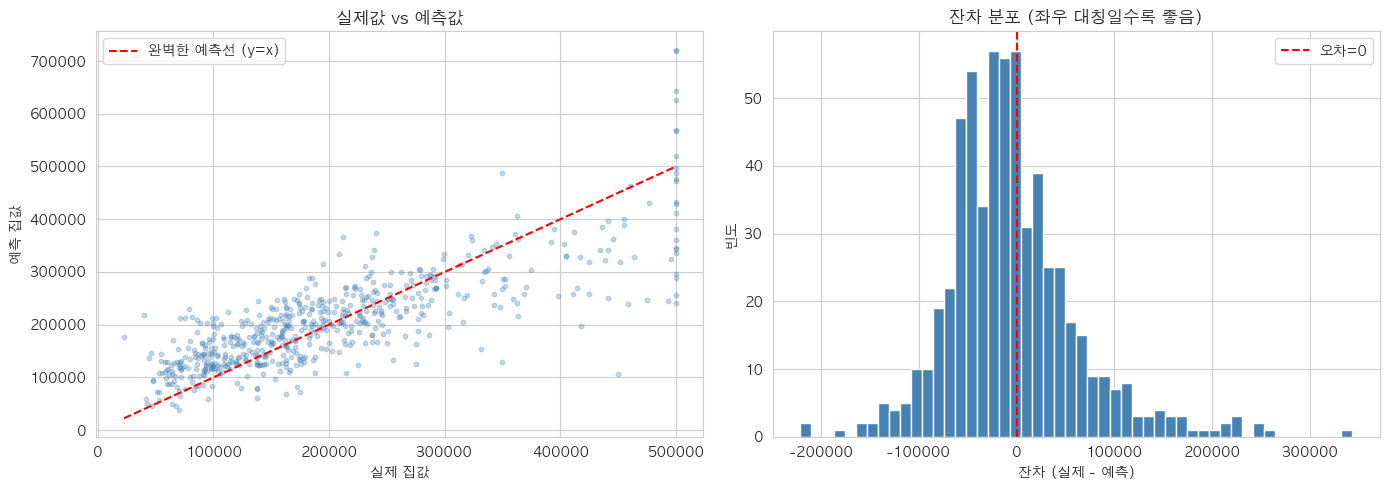

In [27]:
# 실제값 vs 예측값 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 산점도: 이상적이면 y=x 직선 위에 점들이 모여야 함
axes[0].scatter(y_test, y_pred_test, alpha=0.3, color='steelblue', s=10)
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='완벽한 예측선 (y=x)')
axes[0].set_xlabel('실제 집값')
axes[0].set_ylabel('예측 집값')
axes[0].set_title('실제값 vs 예측값')
axes[0].legend()

# 잔차 분포: 0을 중심으로 정규분포여야 이상적
residuals = y_test.values - y_pred_test
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='오차=0')
axes[1].set_xlabel('잔차 (실제 - 예측)')
axes[1].set_ylabel('빈도')
axes[1].set_title('잔차 분포 (좌우 대칭일수록 좋음)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. 모델 구조 비교 — 은닉층 수에 따른 성능

층을 많이 쌓을수록 복잡한 패턴 학습이 가능하지만, 과적합 위험도 커집니다.

In [28]:
model_configs = {
    '얕은 신경망 (1층)' : [64],
    '중간 신경망 (2층)' : [64, 32],
    '깊은 신경망 (3층)' : [128, 64, 32],
}

comp_results = []

for name, units_list in model_configs.items():
    layer_list = []
    for i, u in enumerate(units_list):
        if i == 0:
            layer_list.append(layers.Dense(u, activation='relu',
                                           input_shape=(X_train_s.shape[1],)))
        else:
            layer_list.append(layers.Dense(u, activation='relu'))
    layer_list.append(layers.Dense(1))

    m = keras.Sequential(layer_list)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    m.fit(X_train_s, y_train, epochs=100, batch_size=32,
          validation_split=0.2,
          callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                   restore_best_weights=True)],
          verbose=0)

    yp = m.predict(X_test_s, verbose=0).flatten()
    r2  = r2_score(y_test, yp)
    mae = mean_absolute_error(y_test, yp)
    comp_results.append({'모델': name, 'R2': round(r2,4), 'MAE': round(mae,0)})
    print(f'{name:20s} | R²={r2:.4f} | MAE={mae:,.0f}')

print()
print(pd.DataFrame(comp_results).to_string(index=False))

얕은 신경망 (1층)          | R²=-2.9713 | MAE=194,260
중간 신경망 (2층)          | R²=0.3903 | MAE=62,446
깊은 신경망 (3층)          | R²=0.6703 | MAE=46,780

         모델      R2      MAE
얕은 신경망 (1층) -2.9713 194260.0
중간 신경망 (2층)  0.3903  62446.0
깊은 신경망 (3층)  0.6703  46780.0


## 8. Dropout — 과적합 방지

### Dropout이란?

> 학습 중 뉴런의 일부를 **무작위로 끄고** 나머지만으로 학습  
> → 특정 뉴런에 의존하지 않도록 강제 → **일반화 성능 향상**

```python
layers.Dropout(0.3)   # 30%의 뉴런을 랜덤 비활성화
```

**주의:** Dropout은 **학습(fit) 중에만** 적용됩니다.  
`predict()` 시에는 자동으로 꺼집니다.

### 📝 시험 출제 포인트
- Dropout은 **과적합 방지** 기법
- rate 범위: 0.2 ~ 0.5 가 일반적
- 학습 시만 적용, **예측 시에는 비활성화**

Dropout 미적용 | R²=0.6687 | MAE=46,938
Dropout 적용   | R²=0.6706 | MAE=46,516


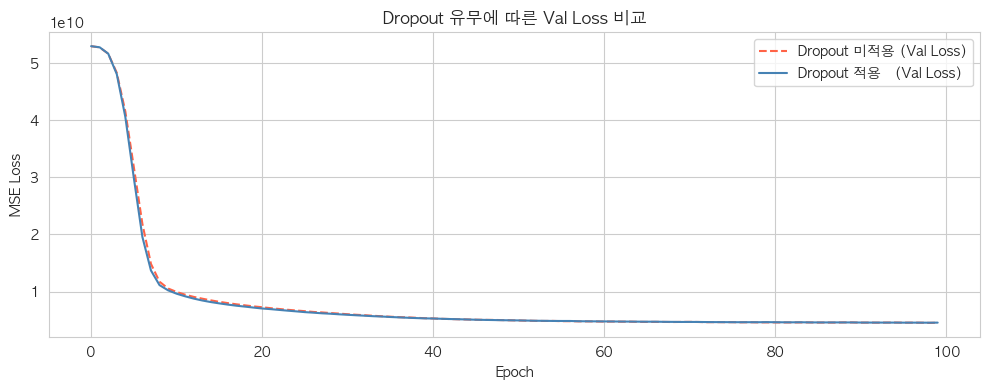

In [29]:
from tensorflow.keras.layers import Dropout

# Dropout 미적용 모델
m_no = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_s.shape[1],)),
    layers.Dense(64,  activation='relu'),
    layers.Dense(32,  activation='relu'),
    layers.Dense(1)
])
m_no.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Dropout 적용 모델 (각 은닉층 뒤에 30% Dropout)
m_drop = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_s.shape[1],)),
    Dropout(0.3),   # 30% 뉴런 랜덤 비활성화
    layers.Dense(64,  activation='relu'),
    Dropout(0.3),
    layers.Dense(32,  activation='relu'),
    layers.Dense(1)
])
m_drop.compile(optimizer='adam', loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

h_no   = m_no.fit(X_train_s, y_train, epochs=100, batch_size=32,
                   validation_split=0.2, callbacks=[es], verbose=0)
h_drop = m_drop.fit(X_train_s, y_train, epochs=100, batch_size=32,
                    validation_split=0.2, callbacks=[es], verbose=0)

for m, h, label in [(m_no, h_no, 'Dropout 미적용'),
                    (m_drop, h_drop, 'Dropout 적용  ')]:
    yp = m.predict(X_test_s, verbose=0).flatten()
    print(f'{label} | R²={r2_score(y_test,yp):.4f} | MAE={mean_absolute_error(y_test,yp):,.0f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(h_no.history['val_loss'],   label='Dropout 미적용 (Val Loss)',
        linestyle='--', color='tomato')
ax.plot(h_drop.history['val_loss'], label='Dropout 적용   (Val Loss)',
        color='steelblue')
ax.set_title('Dropout 유무에 따른 Val Loss 비교')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.show()

---
## ✏️ AICE 딥러닝 핵심 정리

### 모델 구성 순서 (반드시 암기)

```
① 데이터 로드 및 전처리
② X/y 분리 → train_test_split
③ StandardScaler (딥러닝은 필수!)
④ keras.Sequential 모델 구성
⑤ model.compile(optimizer, loss, metrics)
⑥ model.fit(X_train, y_train, epochs, batch_size, validation_split, callbacks)
⑦ model.predict(X_test).flatten()
⑧ 평가 지표 (mae, rmse, r2 / accuracy, f1)
```

### 문제 유형별 출력층 & Loss

| 문제 | 출력 뉴런 | 활성화 | Loss |
|---|---|---|---|
| **회귀** | 1 | 없음 | `mse` |
| **이진분류** | 1 | `sigmoid` | `binary_crossentropy` |
| **다중분류** | 클래스 수 | `softmax` | `categorical_crossentropy` |

### 과적합 방지 방법

| 방법 | 코드 |
|---|---|
| **EarlyStopping** | `patience=10, restore_best_weights=True` |
| **Dropout** | `layers.Dropout(0.3)` |
| **층/뉴런 수 줄이기** | `Dense(64)` → `Dense(32)` |
| **L2 정규화** | `kernel_regularizer=keras.regularizers.l2(0.01)` |